In [1]:

import numpy as np
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent)) 
from commom_utils.systems import *
from commom_utils.ode_system import ODESystem, check_system_ok, SyntheticDataGenerator
from commom_utils.system_config import create_system
from gauss_newton.utils import plot_solution
import numpy as np
import matplotlib.pyplot as plt
from gauss_newton.gauss_newton_math import MultipleShooting, run_optimization


In [2]:
model_name = "Pendulum"
system, c0, theta_true, delta_theta = create_system(model_name)
theta_init = theta_true + delta_theta if delta_theta is not None else theta_true

In [3]:
t0 = 0
t1 = 10
generator_main = SyntheticDataGenerator(system, sigma=1e-15, perturb_initial=True, perturbation_scale=0.0, use_jax=1)

t_batches, measured_batches, state_batches, inp_signals = generator_main.generate(
    c0=c0,
    theta=theta_true,
    time_intervals=[(t0, t1)],
    n_measurements=50
)

generator_debug = SyntheticDataGenerator(system, sigma=0.0, perturb_initial=True, perturbation_scale=0.0, use_jax=1)

t_batches_debug, measured_batches_debug, state_batches_debug, inp_signals_batches_debug = generator_debug.generate(
    c0=c0,
    theta=theta_true,
    time_intervals=[(t0, t1)],
    n_measurements=1000
)

In [4]:
system.n_obs

3

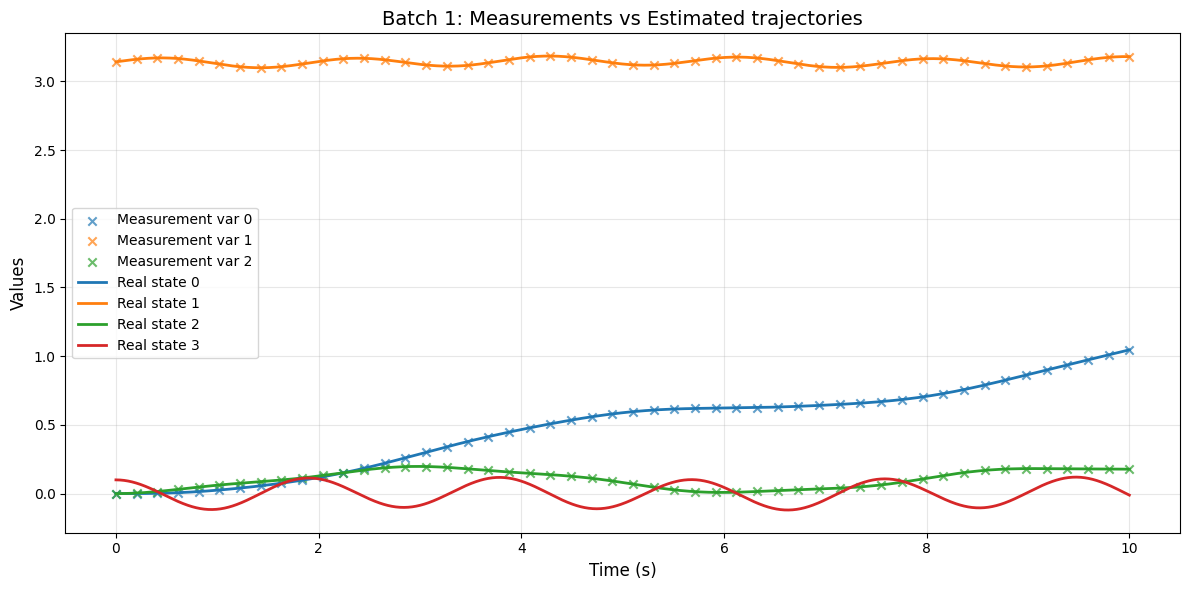

In [5]:
# Для каждого батча (эксперимента) создаём отдельную фигуру или субплот
for batch_idx, (t_batch, t_batch_debug, meas_batch, fill_batch, fill_batch_debug, inp_signals_debug) in enumerate(
        zip(t_batches, t_batches_debug, measured_batches, state_batches, state_batches_debug, inp_signals_batches_debug)):

    plt.figure(figsize=(12, 6))
    
    # 1. Измерения (зелёные крестики) – для каждой переменной отдельный цвет и легенда
    n_meas = meas_batch.shape[1]  # количество измеряемых переменных
    n_inp_signal = system.nu
    for i in range(n_meas):
        plt.scatter(t_batch, meas_batch[:, i], marker='x', label=f'Measurement var {i}', alpha=0.7)


    # 2. Оценочные траектории (сплошные линии) – для каждого состояния
    n_states = fill_batch_debug.shape[1]
    for i in range(n_states):
        plt.plot(t_batch_debug, fill_batch_debug[:, i], '-', label=f'Real state {i}', linewidth=2)

    # for i in range(n_inp_signal):
    #     plt.plot(t_batch_debug, inp_signals_debug[:, i], '-',  label=f'Input signal {i}', linewidth=2)
    
    # 3. Настройки подписей
    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('Values', fontsize=12)
    plt.title(f'Batch {batch_idx+1}: Measurements vs Estimated trajectories', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='best', fontsize=10)
    
    plt.tight_layout()
    plt.show()

Solve batch 0
Iter   0 | time: 23.418s | R_meas: 4.322e-05 | R_cont: 5.260e-03
Solve batch 0
Iter   1 | time: 0.285s | R_meas: 2.024e-06 | R_cont: 2.114e-04
Solve batch 0
Iter   2 | time: 0.293s | R_meas: 1.425e-06 | R_cont: 1.018e-04
Solve batch 0
Iter   3 | time: 0.311s | R_meas: 1.369e-06 | R_cont: 8.405e-05
Solve batch 0
Iter   4 | time: 0.307s | R_meas: 1.360e-06 | R_cont: 6.477e-05
Solve batch 0
Iter   5 | time: 0.292s | R_meas: 1.439e-06 | R_cont: 4.287e-05
Solve batch 0
Iter   6 | time: 0.204s | R_meas: 1.583e-06 | R_cont: 2.122e-05
Solve batch 0
Iter   7 | time: 0.145s | R_meas: 1.515e-06 | R_cont: 6.385e-06
Solve batch 0
Iter   8 | time: 0.150s | R_meas: 9.823e-07 | R_cont: 9.798e-07
Solve batch 0
Iter   9 | time: 0.092s | R_meas: 3.986e-07 | R_cont: 8.550e-08
Solve batch 0
Iter  10 | time: 0.076s | R_meas: 1.164e-07 | R_cont: 5.747e-09
Solve batch 0
Iter  11 | time: 0.071s | R_meas: 2.859e-08 | R_cont: 3.531e-10
Solve batch 0
Iter  12 | time: 0.067s | R_meas: 6.455e-09 | R_c

/home/iachichkanov/autotech/GaussNewton/gauss_newton/utils.py:472: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


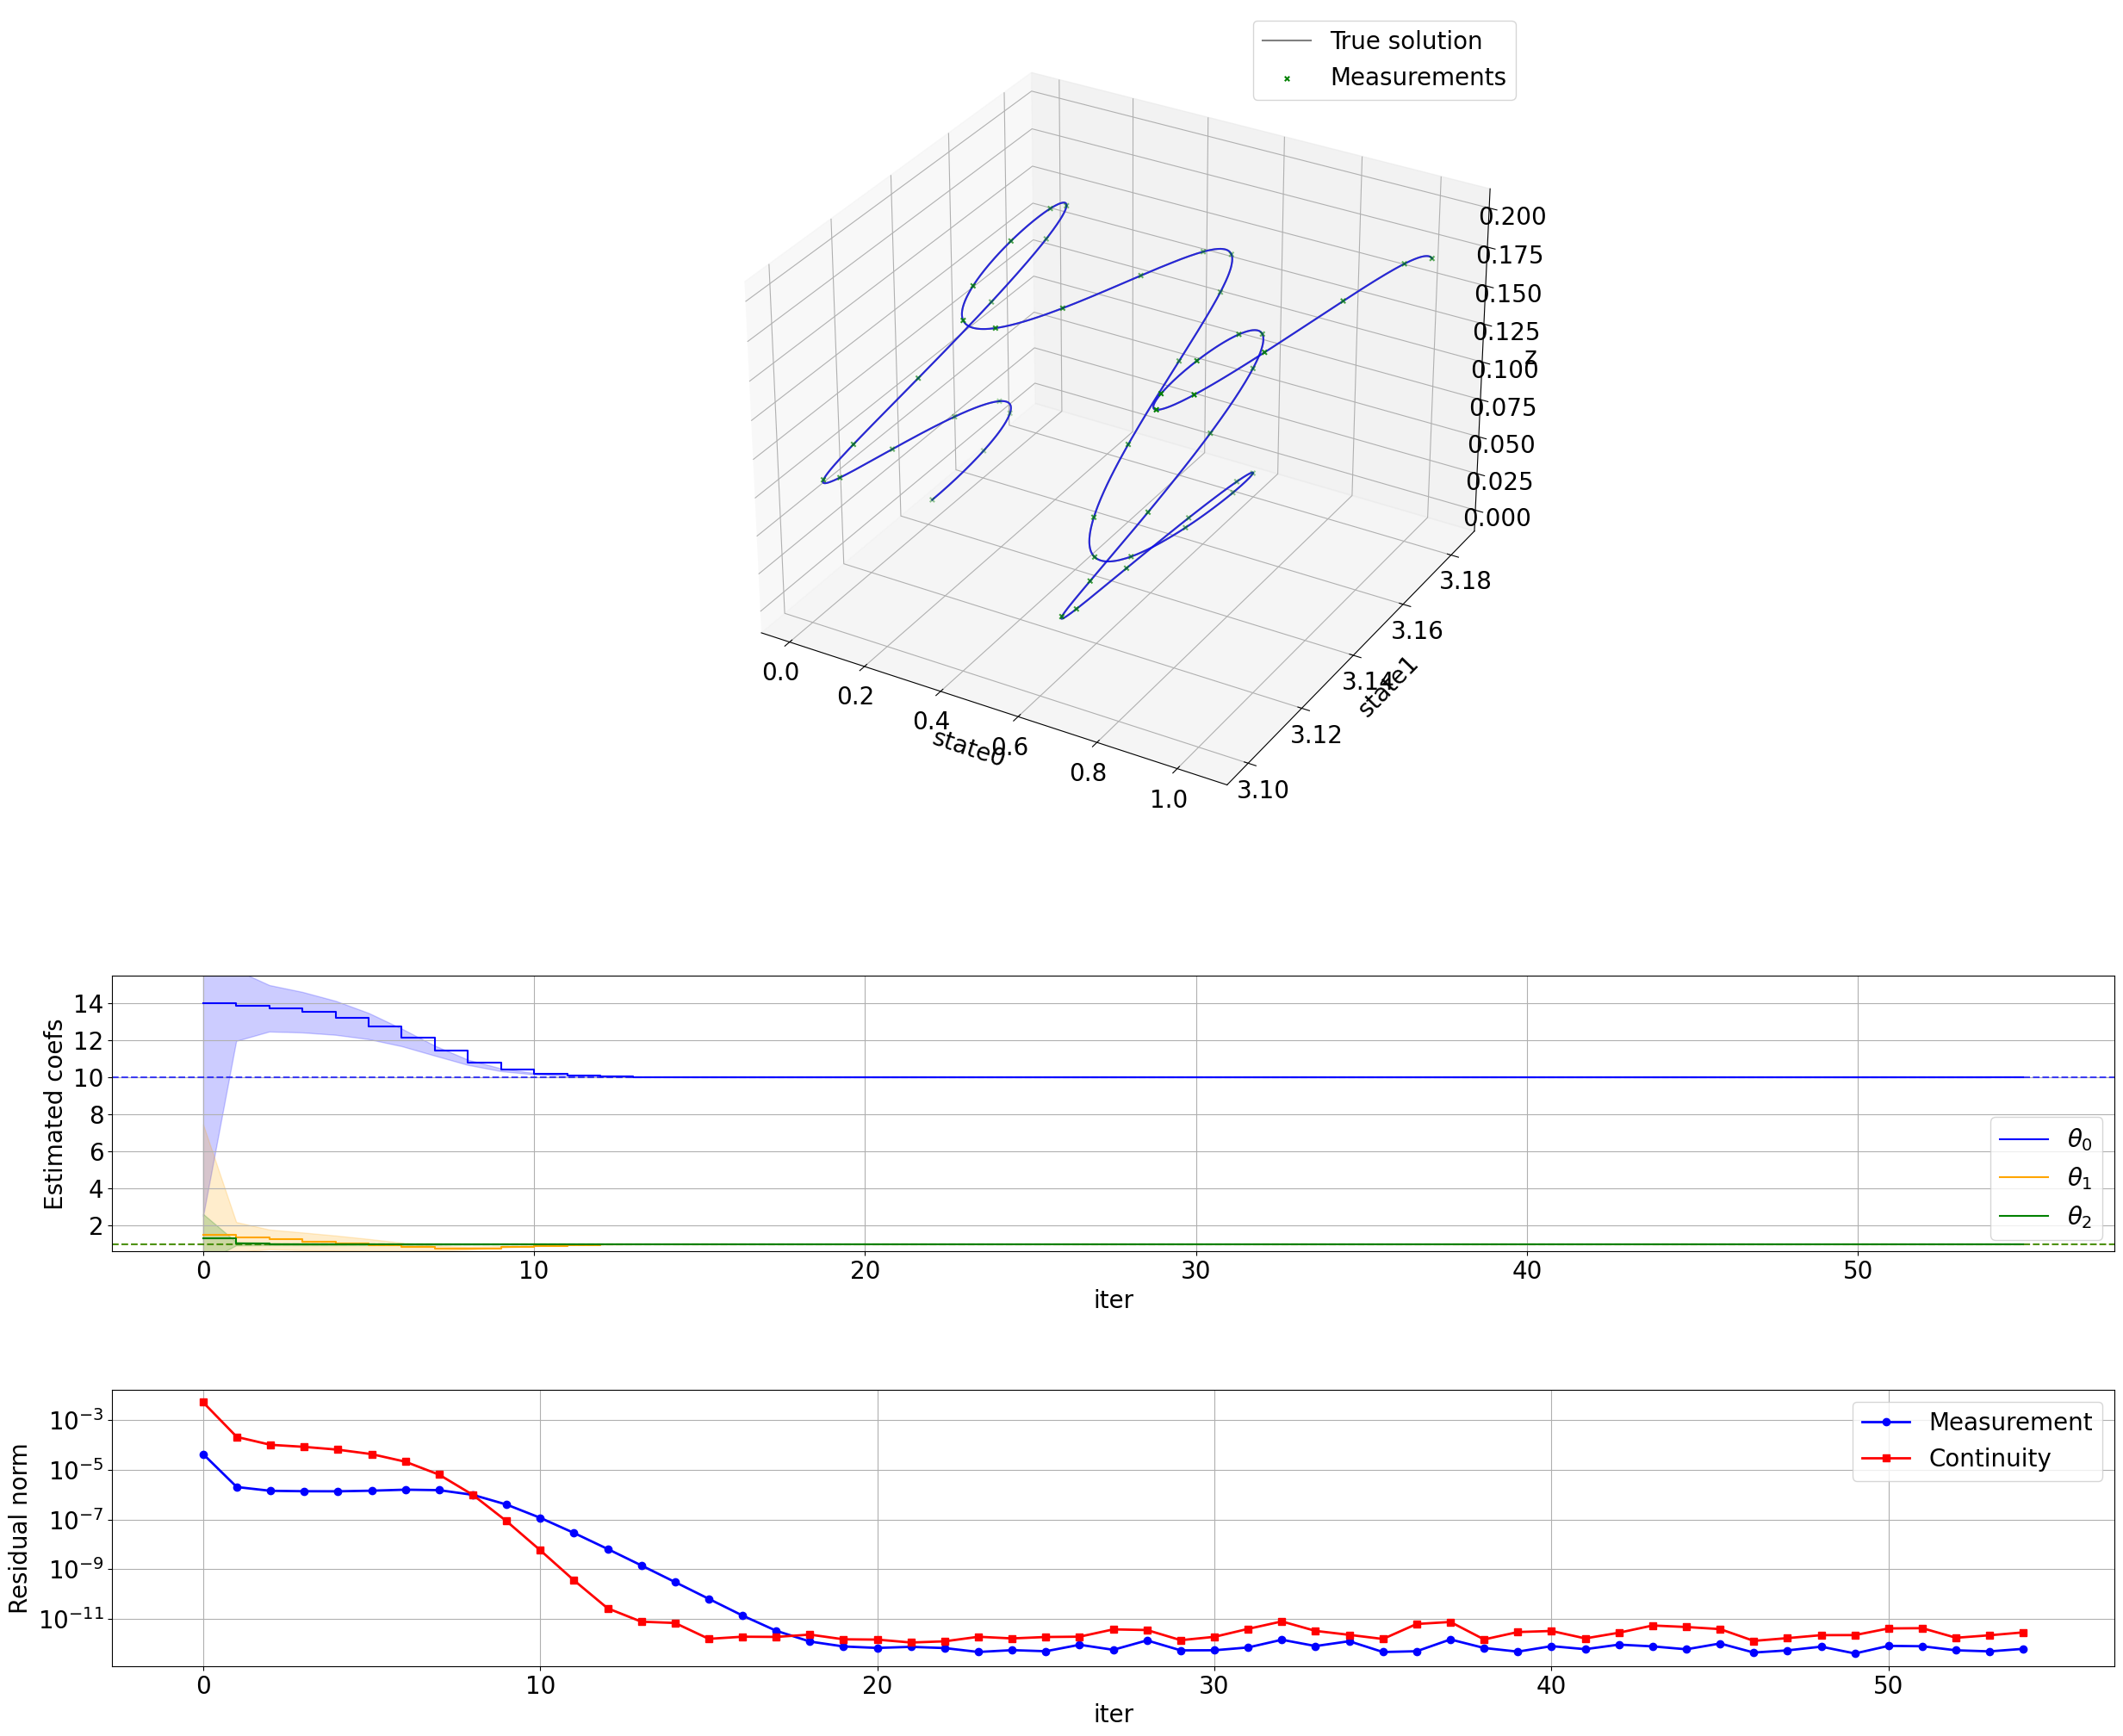

In [6]:
# optimization_config.py (исправленная версия с доверительными интервалами)
import numpy as np
import matplotlib.pyplot as plt

class OptimizationConfig:
    """Конфигурация оптимизации для multiple shooting."""
    def __init__(self, n_obs):
        self.gamma = np.ones(n_obs)      # веса измерений
        self.lambda_ = 0.01                # регуляризация Левенберга-Марквардта
        self.lambda_reg = 0.0001               # дополнительная регуляризация (отключена)
        self.n_iter = 55                   # количество итераций
        self.c0_cost = 1.0                  # вес начальной точки в интервале
        self.validation = False             # режим валидации
        self.mu = 100.0                     # начальный параметр для метода с множителями
        self.n_shoot = 15

def setup_problem(system, config, state_measured_batches, state_full_batches,
                  t_eval_batches, t_eval_debug, state_full_debug, theta_true):
    problem = MultipleShooting(system, N_shoot=config.n_shoot, gamma=config.gamma,
                               c0_cost=config.c0_cost, use_jax=True)
    for state_meas, state_full, t_meas in zip(state_measured_batches, state_full_batches, t_eval_batches):
        problem.add_batch(state_full, state_meas, t_meas)
    problem.full_trajectory = (t_eval_debug, state_full_debug)
    problem.theta_true = theta_true
    return problem

# ====================================================================
# Основной блок (исправлен)
# ====================================================================
if __name__ == "__main__":
    # Предполагается, что у вас уже определены:
    # system (ODE_System)
    # measured_batches, state_batches, t_batches (из синтетических данных)
    # t_batches_debug, state_batches_debug (истинные траектории)
    # theta_true (истинные параметры)
    # theta (начальные параметры)

    config = OptimizationConfig(system.n_obs)
    # При необходимости переопределите параметры:
    problem = setup_problem(system, config,
                            measured_batches, state_batches, t_batches,
                            t_batches_debug, state_batches_debug, theta_true)
    theta0 = theta_init   # theta определена ранее

    theta_full = problem.make_full_theta(theta0, n_iter = 10)
    theta_hist, r_meas_hist, r_cont_hist, theta_full, ci_low_hist, ci_high_hist = run_optimization(
        problem, config, theta_full, system
    )
    # Передаём историю CI в plot_solution
    fig = plt.figure(figsize=(30, 25))
    plot_solution(
        fig, problem, theta_hist,
        plot_xy=0,
        plot_theta=True,
        plot_true_solution=True,
        plot_residuals=True,
        plot_measurements = 1,
        r_meas_hist=r_meas_hist,
        r_cont_hist=r_cont_hist,
        index=-1,
        theta_true=theta_true,
        ci_low_hist=ci_low_hist,    # <-- добавить
        ci_high_hist=ci_high_hist,  # <-- добавить
        param_names=[f'θ_{i}' for i in range( system.np)]
    )

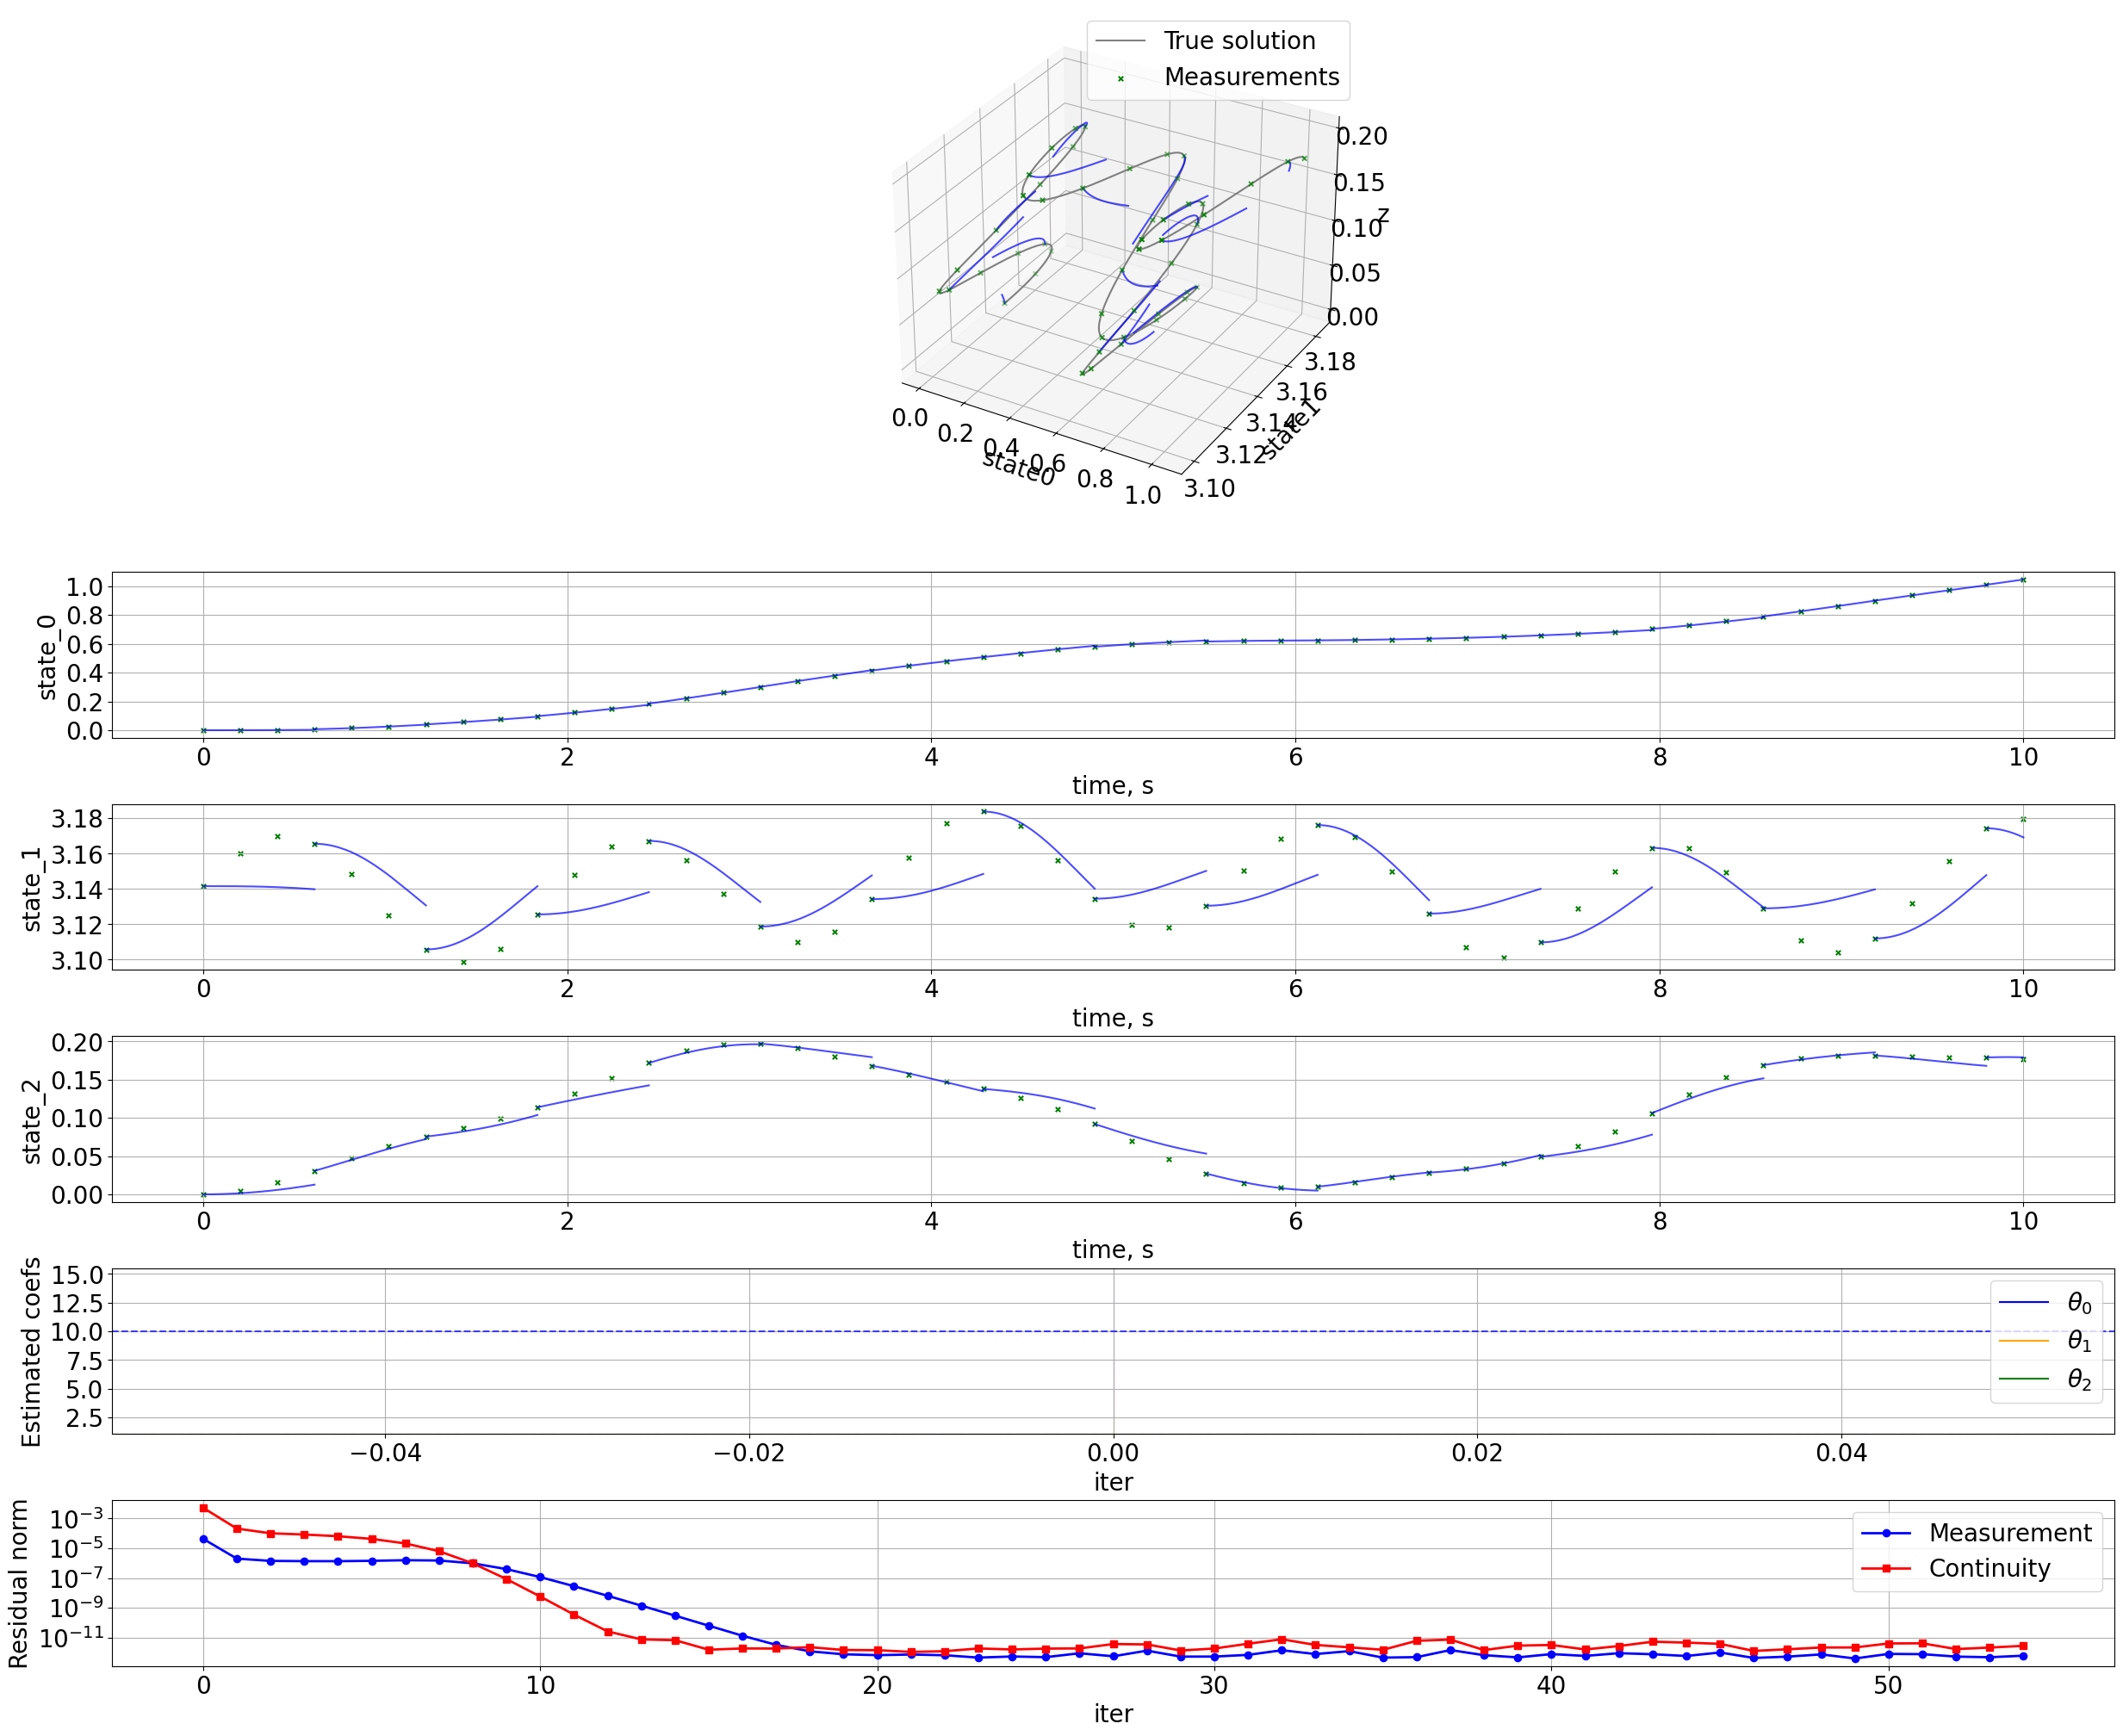

In [8]:
fig = plt.figure(figsize=(30, 25))
plot_solution(
    fig, problem, theta_hist,
    plot_xy=1,
    plot_theta=True,
    plot_true_solution=True,
    plot_residuals=True,
    plot_measurements = 1,
    r_meas_hist=r_meas_hist,
    r_cont_hist=r_cont_hist,
    index=0,
    theta_true=theta_true,
    ci_low_hist=ci_low_hist,    # <-- добавить
    ci_high_hist=ci_high_hist,  # <-- добавить
    param_names=[f'θ_{i}' for i in range( system.np)]
)

In [41]:
theta_true, theta_hist[-1][:len(theta_true)]

(array([ 0.05      , -0.08726646]), array([ 0.05145798, -0.10184656]))

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.animation as animation

fig = plt.figure(figsize=(30, 25))

def animate_gauss(frame):
    fig.clear()
    plt.clf()
    plot_solution(
    fig, 
    problem, 
    theta_hist, 
    plot_xy=0,               # покажет x(t) и y(t)
    plot_theta=1,            # покажет сходимость параметров
    plot_true_solution=True,    # если есть истинная траектория
    plot_residuals=0,        # добавить график невязок
    r_meas_hist=r_meas_hist,    # ваша история невязок измерений
    r_cont_hist=r_cont_hist,     # ваша история невязок непрерывности
    index=frame,                   # последняя итерация
    theta_true=theta_true       # истинные параметры (опционально)
)
anim = animation.FuncAnimation(
    fig, animate_gauss, frames=10, interval=500, repeat=True
)

plt.show()

<Figure size 3000x2500 with 0 Axes>

In [22]:
anim.save("gauss_newton/demo.gif", writer="pillow")

batch 0
batch 0
batch 0
batch 0
batch 0
batch 0
batch 0
batch 0
batch 0
batch 0
batch 0


<Figure size 640x480 with 0 Axes>